In [10]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv('study_marks.csv')
print(f"Shape: {df.shape}")

Shape: (30, 2)


In [36]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

print("Clustering Complete")
print(df['Cluster'].value_counts().sort_index())

Clustering Complete
Cluster
0    10
1    10
2    10
Name: count, dtype: int64


c:\Users\saiya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


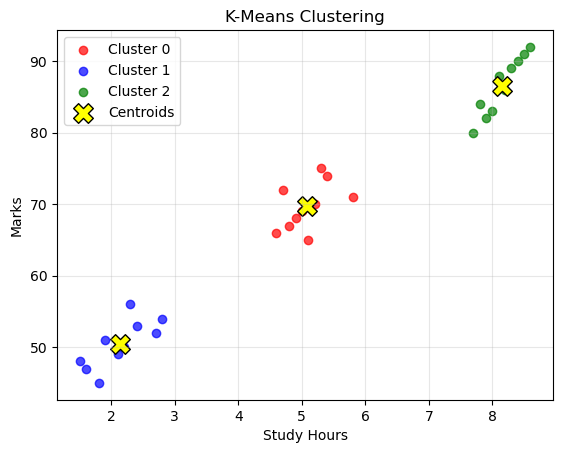

In [12]:

colors = {0: 'red', 1: 'blue', 2: 'green'}
for i, color in colors.items():
    cluster_points = df[df['Cluster'] == i]
    plt.scatter(cluster_points['Study_Hours'], cluster_points['Marks'],
                c=color, label=f'Cluster {i}', alpha=0.7)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1],
            c='yellow', marker='X', s=200, edgecolors='black', label='Centroids')

plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('K-Means Clustering')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
print(f"Clusters: {len(set(clusters))}")

Clusters: 3
